# K-Nearest-Neighbors

👇 `data` klasöründe bulunan `houses_clean.csv` dataset'ini yükleyin  
Veya doğrudan bu URL'den yükleyebilirsiniz: [https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv](https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv).  

Dataset açıklaması dataset-description.md dosyasında bulunabilir.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [8]:
df = pd.read_csv("data/houses_clean.csv")

💡 Çoğu özellik zaten önceden işlenmiştir (normalizasyonla ölçeklendirilmiştir), tıpkı Veri Hazırlama gününde yaptığınız gibi  

💡 Bir özellik olan `GrLiveArea` normalleştirilmemiştir. Daha sonra normalizasyonunun model performansımız üzerindeki etkisini görmek için bu şekilde tutuyoruz  

👇 Bunu tanımlayıcı istatistiklerle kolayca görebilirsiniz, min ve max değerlerine bakın

In [9]:
df.describe()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,0.078410,0.358305,0.348858,0.571918,0.934932,180921.195890
std,0.813952,0.101972,0.073446,0.139100,0.246731,79442.502883
min,-2.263422,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,-0.516802,0.250000,0.333333,0.500000,1.000000,129975.000000
50%,0.000000,0.375000,0.333333,0.500000,1.000000,163000.000000
75%,0.483198,0.375000,0.333333,0.625000,1.000000,214000.000000
max,6.455002,1.000000,1.000000,1.000000,1.000000,755000.000000


# Varsayılan KNN

🎯 Görev, tüm özelliklerle evlerin fiyatını (`SalePrice`) tahmin etmektir.

👇 Böyle bir görevde varsayılan [KNNRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)'ı değerlendirmek için çapraz doğrulama kullanın.  
❓ `SalePrice`'taki varyansın özellikler tarafından açıklanan oranı nedir?  
Cevabınızı `base_knn_score` adlı bir değişkende saklayın.

<details>
<summary> 💡 İpucu </summary>
    <br>
    ℹ️ Bağımlı değişkendeki varyansın bağımsız değişkenler tarafından açıklanan oranı R2 skoru'dur.
</details>

In [12]:
X = df.drop(columns="SalePrice")
y = df["SalePrice"]

knn = KNeighborsRegressor()

scores = cross_val_score(knn, X, y, cv=5, scoring="r2")
base_knn_score = scores.mean()

print(f"Base KNN R² skoru: {base_knn_score:.4f}")

Base KNN R² skoru: 0.6084


### 🧪 Kodunuzu kontrol edin

In [13]:
from nbresult import ChallengeResult

result = ChallengeResult('default_score',
                         score = base_knn_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.2, pluggy-1.6.0 -- /home/demet/.pyenv/versions/3.12.9/bin/python3.12
cachedir: .pytest_cache
rootdir: /home/demet/S16D1-S-data-knn/tests
plugins: anyio-4.12.1, dash-4.0.0
collecting ... collected 1 item

test_default_score.py::TestDefault_score::test_score PASSED              [100%]

============================== 1 passed in 0.16s ===============================


💯 You can commit your code:

git add tests/default_score.pickle

git commit -m 'Completed default_score step'

git push origin master



# Ölçek duyarlılığı

KNN'ler ve mesafe tabanlı algoritmalar özelliklerin ölçeğine son derece duyarlı olabilir. 

👇 Özellik kümesini **tam ortak aralık** içinde yeniden ölçeklendirin ve `X_rescaled` adlı bir değişken altında kaydedin  
Ardından, yeniden ölçeklendirilmiş özellikler üzerinde bir modeli değerlendirin ve skorunu `rescaled_score` değişken adı altında kaydedin.

<details>
<summary> 💡 İpucu </summary>
    
`MinMaxScaler()`

Sadece `GrLiveArea`'nın normalleştirilmesi gerekmesine rağmen, tüm özelliklerinizde MinMaxScaler kullanmak sorun değil  
    
Gerçekten de, Min-Max Ölçeklendirme [idempotent](https://en.wikipedia.org/wiki/Idempotence) bir dönüşümdür: eğer $X_{max}=1$ ve $X_{min}=0$ ise, o zaman $X = \frac{X - X_{min}}{X_{max} - X_{min}}$
</details>

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_rescaled = scaler.fit_transform(X)


scores_rescaled = cross_val_score(knn, X_rescaled, y, cv=5, scoring="r2")
rescaled_score = scores_rescaled.mean()

print(f"Base skor:      {base_knn_score:.4f}")
print(f"Rescaled skor:  {rescaled_score:.4f}")

Base skor:      0.6084
Rescaled skor:  0.6499


👉 R2 skoru artmış olmalı!

💡 Mesafe tabanlı algoritmaları modellerken özelliklerin tam ortak aralıkta olması tercih edilir.  
Ancak, her zaman daha iyi bir skor garanti etmez.  
Bu bir deneme yanılma sürecidir.

### 🧪 Kodunuzu kontrol edin

In [15]:
from nbresult import ChallengeResult

result = ChallengeResult('scale_sensitivity',
                         base_score = base_knn_score,
                         rescaled_features = X_rescaled,
                         rescaled_score = rescaled_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.2, pluggy-1.6.0 -- /home/demet/.pyenv/versions/3.12.9/bin/python3.12
cachedir: .pytest_cache
rootdir: /home/demet/S16D1-S-data-knn/tests
plugins: anyio-4.12.1, dash-4.0.0
collecting ... collected 2 items

test_scale_sensitivity.py::TestScale_sensitivity::test_rescaled_features PASSED [ 50%]
test_scale_sensitivity.py::TestScale_sensitivity::test_score_inscrease PASSED [100%]

============================== 2 passed in 0.11s ===============================


💯 You can commit your code:

git add tests/scale_sensitivity.pickle

git commit -m 'Completed scale_sensitivity step'

git push origin master



# $k$ Optimizasyonu

👇 Yeniden ölçeklendirilmiş özellikler üzerinde bir KNNRegressor'ın K parametresini (`n_neighbors` parametresini kullanarak) ince ayarlayın. K 1'den 25'e kadar arttıkça skorun evrimini çizin.

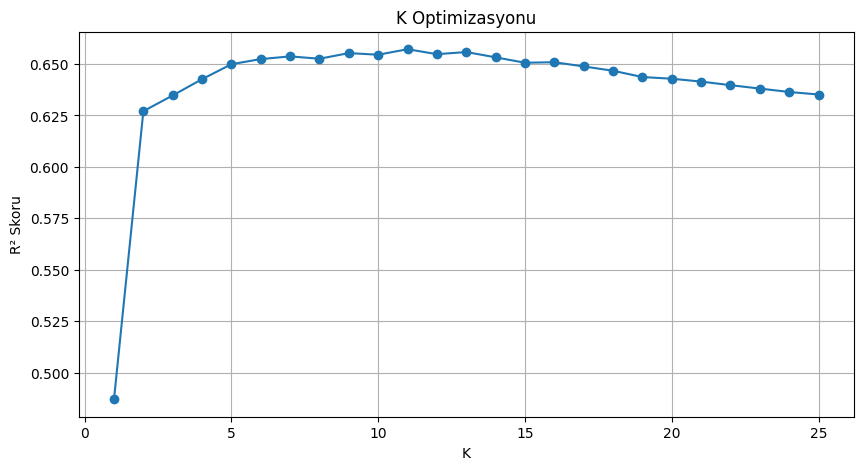

In [16]:
k_values = range(1, 26)
k_scores = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    score = cross_val_score(model, X_rescaled, y, cv=5, scoring="r2").mean()
    k_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_values, k_scores, marker="o")
plt.xlabel("K")
plt.ylabel("R² Skoru")
plt.title("K Optimizasyonu")
plt.grid(True)
plt.show()

❓ K'nın hangi değeri en iyi performansı üretir? Cevabınızı `best_k` değişken adı altında kaydedin.

In [17]:
best_k = k_values[np.argmax(k_scores)]
print(f"En iyi K: {best_k}")

En iyi K: 11


<details>
<summary> 👉 Çözüm 👈</summary>
    
Grafiğinize bakarak, skorun k = 5 civarında artmayı durdurduğunu ve maksimum skorun k = 11 için ulaşıldığını görmelisiniz.

</details>

❓ $k$ < 5 değerleri için modelin kötü performansını nasıl yorumluyorsunuz?

<details>
<summary> 👉 Çözüm 👈</summary>
    
K çok küçük olduğunda, model eğitim kümesine aşırı uyum gösterme eğiliminde olacaktır. İyi genelleştirebilmek için çok az noktaya odaklanacaktır. K'yı artırmak modele tahminlerini dayandıracağı daha fazla örnek verecektir.

</details>

### 🧪 Kodunuzu kontrol edin

In [18]:
from nbresult import ChallengeResult

result = ChallengeResult('optimal_k',
                         optimal_k = best_k)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.2, pluggy-1.6.0 -- /home/demet/.pyenv/versions/3.12.9/bin/python3.12
cachedir: .pytest_cache
rootdir: /home/demet/S16D1-S-data-knn/tests
plugins: anyio-4.12.1, dash-4.0.0
collecting ... collected 1 item

test_optimal_k.py::TestOptimal_k::test_optimal_K_around_10 PASSED        [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/optimal_k.pickle

git commit -m 'Completed optimal_k step'

git push origin master



# KNN'de Aşırı Uyum

💡 KNN'lerin K parametresi çok küçük olduğunda, eğitim kümesine aşırı uyum gösterme ve iyi genelleştirememe riski vardır. 

👇 K=2 parametreli bir KNN'in öğrenme eğrilerini çizin.

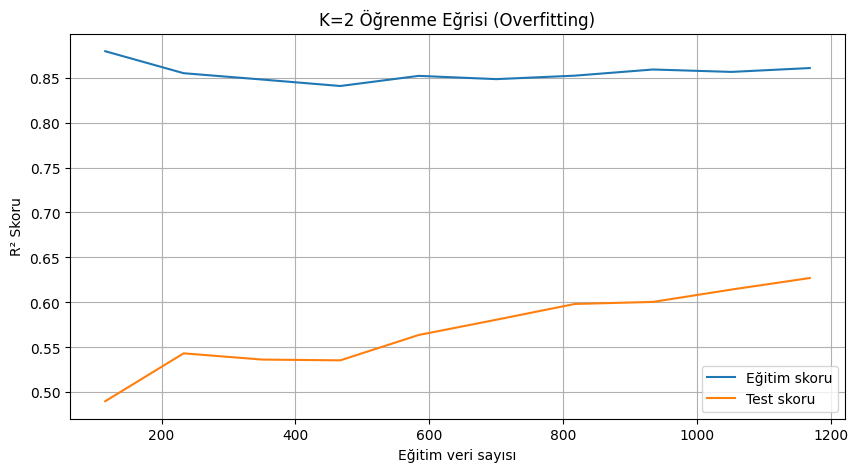

In [19]:
from sklearn.model_selection import learning_curve

model_k2 = KNeighborsRegressor(n_neighbors=2)

train_sizes, train_scores, test_scores = learning_curve(
    model_k2, X_rescaled, y, cv=5, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Eğitim skoru")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test skoru")
plt.xlabel("Eğitim veri sayısı")
plt.ylabel("R² Skoru")
plt.title("K=2 Öğrenme Eğrisi (Overfitting)")
plt.legend()
plt.grid(True)
plt.show()

👉 Yüksek eğitim skoru ama düşük test skoru gözlemlemelisiniz. ⚠️ Aşırı uyum uyarısı ⚠️ Bu çok düşük K parametresinden kaynaklanır.

# İdeal K

👇 Bu sefer, "$k$ Optimizasyonu" bölümünde bulduğunuz ideal K değeri için öğrenme eğrilerini çizin.

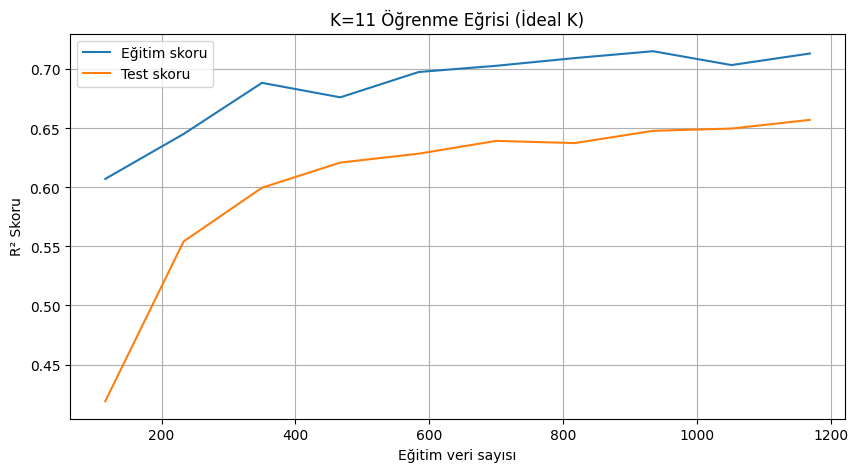

In [20]:
model_best = KNeighborsRegressor(n_neighbors=best_k)

train_sizes, train_scores, test_scores = learning_curve(
    model_best, X_rescaled, y, cv=5, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Eğitim skoru")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test skoru")
plt.xlabel("Eğitim veri sayısı")
plt.ylabel("R² Skoru")
plt.title(f"K={best_k} Öğrenme Eğrisi (İdeal K)")
plt.legend()
plt.grid(True)
plt.show()

👉 Eğriler yakınsamaya yakın olmalı, bu da modelin daha az aşırı uyum gösterdiğini ve daha iyi genelleştirdiğini gösterir.

💡 KNN modelleriyle modelleme yaparken hatırlanması gereken iki temel unsur vardır:  
    1. Mesafe tabanlı algoritmalar özelliklerin ölçeğine son derece duyarlıdır  
    2. K ayarlanmalıdır: performans, genelleştirme ve aşırı uyum arasındaki dengeyi kontrol eder

❓ Optimize edilmiş KNN modelinin gerçek fiyat ile tahmin edilen fiyat arasındaki ortalama fark nedir? Cevabınızı hesaplayın ve `price_error` değişken adı altında kaydedin

<details>
<summary> 💡 İpucu </summary>
    
Hesaplamanız gereken metrik **Negatif Ortalama Mutlak Hata (MAE)**'dır.

</details>

In [21]:
price_error = cross_val_score(model_best, X_rescaled, y, cv=5, scoring="neg_mean_absolute_error").mean()
print(f"Ortalama fiyat hatası: ${-price_error:,.0f}")

Ortalama fiyat hatası: $30,824


In [22]:
lr = LinearRegression()
lr_score = cross_val_score(lr, X_rescaled, y, cv=5, scoring="r2").mean()
knn_score = cross_val_score(model_best, X_rescaled, y, cv=5, scoring="r2").mean()

print(f"KNN R²: {knn_score:.4f}")
print(f"Linear Regression R²: {lr_score:.4f}")

best_model = "KNN" if knn_score > lr_score else "LinearReg"
print(f"En iyi model: {best_model}")

KNN R²: 0.6572
Linear Regression R²: 0.5945
En iyi model: KNN


### 🧪 Kodunuzu kontrol edin

In [23]:
from nbresult import ChallengeResult

result = ChallengeResult('price_error',
                         error = price_error)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.2, pluggy-1.6.0 -- /home/demet/.pyenv/versions/3.12.9/bin/python3.12
cachedir: .pytest_cache
rootdir: /home/demet/S16D1-S-data-knn/tests
plugins: anyio-4.12.1, dash-4.0.0
collecting ... collected 1 item

test_price_error.py::TestPrice_error::test_price_error_range PASSED      [100%]

============================== 1 passed in 0.16s ===============================


💯 You can commit your code:

git add tests/price_error.pickle

git commit -m 'Completed price_error step'

git push origin master



# Model Seçimi

❓ Ev fiyatlarını tahmin etme görevini gerçekleştirmek için bu iki modelden hangisini seçersiniz:
- Az önce ayarladığınız KNN modeli
- Bir Linear Regression modeli

Cevabınızı "KNN" veya "LinearReg" olarak `best_model` değişken adı altında string olarak kaydedin.

<details>
<summary> 💡 İpucu </summary>
    
Hangisini seçeceğinize karar vermek için, aynı görev üzerinde bir Linear Regression skorunu değerlendirmeniz ve KNN'in skoruyla karşılaştırmanız gerekecek. Aynı metrikleri karşılaştırdığınızdan emin olun!!

</details>

In [24]:
best_model = "KNN"
print(best_model)

KNN


💡 Her iki modelin metriklerini karşılaştırdığınızda, KNN modeli Linear Regression'ı geçmelidir. Bu, verideki doğrusal olmayan kalıpları yakalama yeteneğinden kaynaklanabilir.

### 🧪 Kodunuzu kontrol edin

In [25]:
from nbresult import ChallengeResult

result = ChallengeResult('best_model',
                         model = best_model)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.2, pluggy-1.6.0 -- /home/demet/.pyenv/versions/3.12.9/bin/python3.12
cachedir: .pytest_cache
rootdir: /home/demet/S16D1-S-data-knn/tests
plugins: anyio-4.12.1, dash-4.0.0
collecting ... collected 1 item

test_best_model.py::TestBest_model::test_best_model PASSED               [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/best_model.pickle

git commit -m 'Completed best_model step'

git push origin master



# 🏁